## <center> Machine Learning from Scratch at ETH Zurich
## <center> 9. Deep Neural Network - Multilayer Perceptron
### <center> Zhaorui Gong &nbsp; 宫兆瑞
                                                                                               ————参考李沐等《动手学深度学习》第四章

## 9.1 多层感知机的从零开始实现
为了与之前softmax回归进行比较，我们仍使用Fashion MNIST数据集
### 9.1.1 初始化模型参数

In [1]:
import torch
from torch import nn
from d2l import torch as d2l
from utils_MLFS import train_classifier as train

In [3]:
batch_size  =256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
num_imputs = 784
num_outputs = 10
num_hidden = 256  # hyperparameter
W1 = nn.Parameter(torch.randn(num_imputs, num_hidden, requires_grad=True) * 0.01)  # randn 是standard normal，乘0.01使标准差变为0.01
b1 = nn.Parameter(torch.zeros(num_hidden, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hidden, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))
params = [W1, b1, W2, b2]

### 9.1.2 激活函数

In [6]:
def relu(X):
    zeros = torch.zeros_like(X)
    return torch.max(zeros, X)

### 9.1.3 模型

In [9]:
def net(X):
    X = X.reshape((-1, num_imputs))   # 展平，确保输入列是784
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2

### 9.1.4 损失函数
这里直接调用高级API中的交叉熵损失，这包含了softmax和CE Loss的计算。

In [12]:
loss = nn.CrossEntropyLoss(reduction='none')   # reduction='none': not to aggregate the loss values across the batch

### 9.1.5 训练

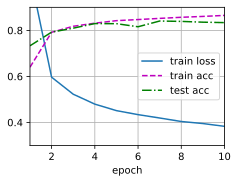

In [15]:
num_epochs, lr = 10, 0.1  # 与8.5节作对照
updater = torch.optim.SGD(params, lr=lr)
train.train_softmax(net, train_iter, test_iter, loss, num_epochs, updater)

## 9.2 多层感知机的简洁实现 - 现代DL库

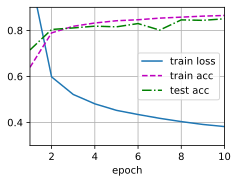

In [17]:
net = torch.nn.Sequential(
    nn.Flatten(),
    nn.Linear(num_imputs, num_hidden, bias=True),
    nn.ReLU(),
    nn.Linear(num_hidden, num_outputs, bias=True)
)     # 模型的定义是关键区别

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)
net.apply(init_weights)
batch_size, lr, num_epochs = 256, 0.1, 10
updater = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train.train_softmax(net, train_iter, test_iter, loss, num_epochs, updater)

## 9.3 多项式回归理解过拟合与欠拟合
### 9.3.1 生成多项式回归的数据集
$$
y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6\frac{x^3}{3!} + \epsilon, where \; \epsilon \; \sim \;N(0, 0.1^2)
$$
我们用阶乘来scale高次幂，这样可以避免高次幂带来很大的梯度值。

In [19]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
from utils_MLFS import train_classifier as trn

In [20]:
max_degree = 20
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)   # 分配大量数组空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train+n_test, 1))   # x，取200个1维
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i+1)  # gamma(n+1) = n!   # x代入多项式的值
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)  # 训练用y值

In [21]:
# np ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) for x in [true_w, features, poly_features, labels]]
print(features[:2])
print(poly_features[:2, :])
print(labels[:2])

tensor([[ 0.6526],
        [-1.1774]])
tensor([[ 1.0000e+00,  6.5256e-01,  2.1292e-01,  4.6313e-02,  7.5556e-03,
          9.8609e-04,  1.0725e-04,  9.9978e-06,  8.1552e-07,  5.9131e-08,
          3.8586e-09,  2.2891e-10,  1.2448e-11,  6.2485e-13,  2.9125e-14,
          1.2671e-15,  5.1677e-17,  1.9836e-18,  7.1914e-20,  2.4699e-21],
        [ 1.0000e+00, -1.1774e+00,  6.9314e-01, -2.7204e-01,  8.0074e-02,
         -1.8856e-02,  3.7002e-03, -6.2237e-04,  9.1597e-05, -1.1983e-05,
          1.4109e-06, -1.5102e-07,  1.4817e-08, -1.3420e-09,  1.1286e-10,
         -8.8589e-12,  6.5191e-13, -4.5151e-14,  2.9534e-15, -1.8302e-16]])
tensor([ 5.3466, -0.3466])


### 9.3.2 模型定义

In [23]:
def evaluate_loss(net, data_iter, loss):
    '''评估给定数据集上模型的损失'''
    metric = trn.Accumulator(2)  # 损失的总和，样本数
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [24]:
def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    '''多项式回归的训练函数'''
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]    # 直接转换为1维行向量，取消所有嵌套tensor。
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = trn.Animator(xlabel='epoch', ylabel='loss', yscale='log', xlim=[1, num_epochs], ylim=[1e-3, 1e2], legend=['train', 'test'])
    for epoch in range(num_epochs):
        trn.train_epoch_softmax(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 10 == 0:
            animator.add(epoch+1, (evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

### 9.3.3 正常拟合
我们首先使用三阶多项式，它与数据生成函数的阶数相同。因此结果应该是，该模型能有效降低训练与测试损失，学习到的参数也与生成时使用的 w=[5, 1.2, -3.4, 5.6] 相接近。

weight: [[ 4.9976087  1.1833246 -3.3914404  5.6158214]]


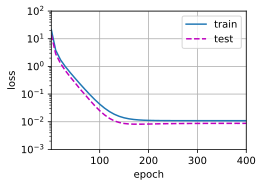

In [26]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

### 9.3.4 欠拟合
再使用线性拟合。从多项式特征中选择前两个维度，即bias和x。我们预期训练损失下降会很慢。

weight: [[3.465471  4.3824854]]


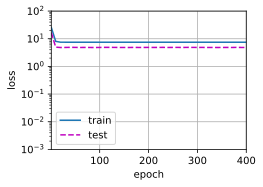

In [28]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

### 9.3.5 过拟合
最后，我们尝试实用一个阶数过高的多项式来训练模型。在这种情况下，没有足够的数据用于学到高阶系数接近0的值（由于正态噪声low-tail），因此噪声很容易干扰模型。虽然训练损失可以有效降低，但测试损失仍然很高。这说明复杂模型对数据造成了过拟合。

weight: [[ 4.95833158e+00  1.31094384e+00 -3.18750525e+00  5.06040096e+00
  -5.73176563e-01  1.52837563e+00 -7.57225081e-02 -2.64361873e-02
   3.06649297e-03 -2.44418234e-02  1.23182066e-01 -1.91234658e-03
  -2.20966414e-01  8.00228864e-02 -5.13401697e-04 -1.61800891e-01
   2.78542917e-02  2.21083630e-02 -1.68279141e-01  1.16789550e-01]]


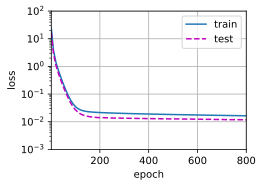

In [30]:
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:], num_epochs=800)

## 9.4 正则化与权重衰减
### 9.4.1 参数初始化——以高维线性回归为例
用于生成数据的公式如下：
$$
y = 0.05 + \sum_{i=1}^{d}0.01x_i + \epsilon, \;where \; \; \epsilon \sim N(0, 0.01^2)
$$
注意，label y是输入x的线性函数。为了使过拟合效果更明显，我们使用d=200，并且只用20个样本。

In [32]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l
from utils_MLFS import train_classifier as trn

In [33]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05   # 初始w全为0.01
train_data = d2l.synthetic_data(true_w, true_b, n_train)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
train_iter = d2l.load_array(train_data, batch_size)
test_iter = d2l.load_array(test_data, batch_size)

### 9.4.2 从零开始实现权重衰减

In [35]:
def init_params():
    '''随机初始化模型参数'''
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

def l2_penalty(w):
    '''定义l2范数惩罚'''
    return torch.sum(w.pow(2), axis=0) / 2

In [36]:
def train(lambd):
    '''定义权重衰减的训练函数'''
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs = 100
    lr = 0.003
    animator = trn.Animator(xlabel='epochs', ylabel='loss', yscale='log', xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了l2范数惩罚项，广播机制使l2_penalty(w)复制为一个长度为batch_size的向量。
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch+1) % 5 == 0:
            animator.add(epoch+1, (d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net, test_iter, loss)))
    print(f'w的L2范数是：{torch.norm(w).item()}')

w的L2范数是：13.096263885498047


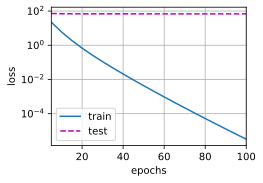

In [37]:
# 情境1：忽略正则化，直接训练。可以预见，测试误差并不会下降，说明模型出现严重过拟合
train(lambd=0)

w的L2范数是：0.0254546906799078


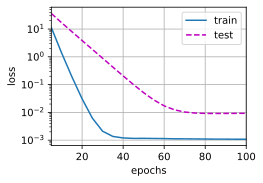

In [38]:
# 情景2：使用适当的lambda进行权重衰减训练。预期测试误差也会减小。
train(lambd=6)

### 9.4.3 权重衰减的简洁实现
由于权重衰减在神经网络优化中非常常用，在现代深度学习框架中，权重衰减被集成到优化算法中，以便结合任何损失函数使用。

此外，集成在运算上的好处是，允许在不增加任何额外的计算开销的情况下向算法中加入权重衰减。由于更新的权重衰减部分 仅依赖于每个参数的当前值，因此优化器必须至少接触每个参数一次。注意默认情况下torch会同时衰减w和b，这里我们只设置weight_decay，所以偏置b不会衰减。

In [40]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs = 100
    lr = 0.003
    trainer = torch.optim.SGD([
        {"params":net[0].weight, 'weight_decay':wd},
        {"params":net[0].bias}
    ], lr = lr)
    animator = trn.Animator(xlabel='epochs', ylabel='loss', yscale='log', xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch+i) % 5 == 0:
            animator.add(epoch+1, (d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net, test_iter, loss)))
    print(f'w的L2范数：{net[0].weight.norm().item()}')   # net[0]就是seq的第一层，即Linear，再调用它的weight.

w的L2范数：13.570547103881836


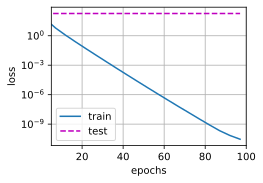

In [41]:
# 情境1：忽略正则化，直接训练。同样地，测试误差并不会下降，模型出现严重过拟合。但用框架会更快也更容易实现。
train_concise(wd=0)

w的L2范数：0.1195542961359024


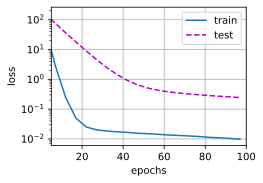

In [42]:
# 情景2：使用适当的lambda进行权重衰减训练。同样地，预期测试误差也会减小。
train_concise(wd=6)

## 9.5 暂退法 (Dropout)
### 9.5.1 从零开始实现暂退法
思想：从Unif[0,1]中取样，样本数与对应的隐藏层维度一样，然后保留对应样本大于p（hyperparam）的nodes，把其他的权重在本层设为0。注意放缩保留的部分：将剩余部分除以 1 - dropout.

In [44]:
import torch
from torch import nn
from d2l import torch as d2l
from utils_MLFS import train_classifier as trn

In [45]:
def dropout_layer(X, dropout):
    '''随机丢弃1-dropout部分的节点'''
    assert dropout >= 0 and dropout <= 1
    if dropout == 1:  # 所有节点都被丢弃
        return torch.zeros_like(X)
    if dropout == 0:  # 所有节点都被保留，没有暂退
        return X
    mask = (torch.rand(X.shape) > dropout).float()   # torch.rand()就是均匀随机，参数是shape。.float()把boolean变成0和1
    return mask * X / (1-dropout)  # renormalization

In [46]:
X = torch.arange(16, dtype=torch.float32).reshape(2, 8)
print(X)
print(dropout_layer(X, 0))
print(dropout_layer(X, 0.5))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  0.,  6.,  0.,  0.,  0.,  0.],
        [16.,  0., 20., 22., 24.,  0., 28.,  0.]])


这里我们继续使用notebook 8中的Fashion-MNIST数据集，定义有2个hidden layers的MLP。以下是模型参数：

In [48]:
num_inputs, hidden1, hidden2, num_outputs = 784, 256, 256, 10
dropout1, dropout2 = 0.2, 0.5

In [49]:
class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, hidden1, hidden2, is_training=True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, hidden1)
        self.lin2 = nn.Linear(hidden1, hidden2)
        self.lin3 = nn.Linear(hidden2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        if self.training:   # 只有在训练时使用dropout
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out

net = Net(num_inputs, num_outputs, hidden1, hidden2)

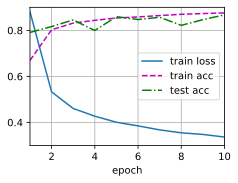

In [50]:
## 接下来进行训练，与前面的过程类似
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
trn.train_softmax(net, train_iter, test_iter, loss, num_epochs, trainer)

### 9.5.2 Dropout的简洁实现
秩序在全连接层后加入Dropout层即可。测试时，Dropout层仅传递数据

In [52]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout1),
                    nn.Linear(256, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout2),
                    nn.Linear(256, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

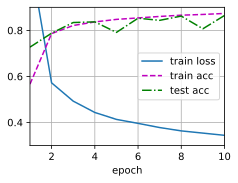

In [53]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
trn.train_softmax(net, train_iter, test_iter, loss, num_epochs, trainer)

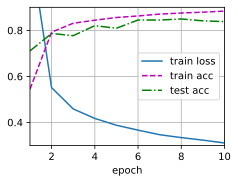

In [54]:
# 我们尝试取消、交换两层Dropout的比例，看看效果如何
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),   # 没有dropout, 预期过拟合
                    nn.Linear(256, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
print("The loss curves without dropout:")
trn.train_softmax(net, train_iter, test_iter, loss, num_epochs, trainer)

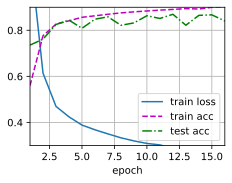

In [64]:
# 没有dropout, 预期过拟合
num_epochs = 16
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
print("The loss curves with reversed dropout layers: the first larger, the second smaller")
trn.train_softmax(net, train_iter, test_iter, loss, num_epochs, trainer)

训练误差趋于0，甚至有时出现数值不稳定的爆炸，同时测试精度反复，这说明模型不再学习特征，而是在“背诵”噪声。去掉Dropout就像是拆掉了赛车的防撞墙，虽然在平直路面上跑得更快（训练误差更低），但一旦遇到颠簸（梯度波动），车就容易直接翻掉。